# Projeto de Machine Learning - Adult Income Census

**Membros do grupo:**
Giovanna Barros Scalco
Mariana Rocha Gomes

**Objetivo:** Realizar uma análise exploratória abrangente do dataset Adult Income Census, entendendo estrutura, qualidade, distribuições e relações entre variáveis, preparando o terreno para a etapa de classificação.

**Dataset original:** https://www.kaggle.com/datasets/anaghakp/adult-income-census

In [5]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
RANDOM_STATE = 42

# 1. Carregamento e inspeção inicial dos dados

In [6]:
df = pd.read_csv("https://raw.githubusercontent.com/scalcogigi/machine-learning-adult-census-analysis/refs/heads/main/data/adult-income.csv")
print("Shape do dataset:", df.shape)
df.head()

Shape do dataset: (31947, 12)


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,native.country,income
0,17,Private,148522,11th,7,Never-married,occupation,Own-child,White,Male,United-States,<=50K
1,17,Private,93235,12th,8,Never-married,occupation,Own-child,White,Female,United-States,<=50K
2,17,Private,184924,9th,5,Never-married,occupation,Own-child,White,Male,United-States,<=50K
3,17,Private,116626,11th,7,Never-married,occupation,Own-child,White,Male,United-States,<=50K
4,17,Private,209949,11th,7,Never-married,occupation,Own-child,White,Female,United-States,<=50K


### 1.1 Descrição das features

| Coluna | Tipo | Descrição |
|---|---|---|
| `age` | numérica | Idade do indivíduo |
| `workclass` | categórica | Tipo de vínculo empregatício  |
| `fnlwgt` | numérica | Estima quantas pessoas na população aquele registro representa |
| `education` | categórica (ordinal) | Nível de escolaridade |
| `education.num` | numérica | Outra versão de `education` (anos de estudo) |
| `marital.status` | categórica | Estado civil |
| `occupation` | categórica | Ocupação profissional |
| `relationship` | categórica | Papel familiar |
| `race` | categórica | Raça declarada |
| `sex` | categórica | Sexo (Male/Female) |
| `native.country` | categórica | País de origem |
| `income` | categórica (**target**) | Faixa de renda: `<=50K` ou `>50K` |

**Observação:** `education` e `education.num` carregam a mesma informação em formatos diferentem, `education.num` será usada para modelagem e `education` apenas para visualização.

In [7]:
print("Número de instâncias:", df.shape[0]) # Pega o número de instâncias
print("Número de features:", df.shape[1] - 1, "(+ 1 target)") # Pega o número de colunas + 1 que queremos prever
print()


Número de instâncias: 31947
Número de features: 11 (+ 1 target)



In [8]:
df.info() # Usa str ao invés de object por documentação do pandas

<class 'pandas.DataFrame'>
RangeIndex: 31947 entries, 0 to 31946
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             31947 non-null  int64
 1   workclass       31947 non-null  str  
 2   fnlwgt          31947 non-null  int64
 3   education       31947 non-null  str  
 4   education.num   31947 non-null  int64
 5   marital.status  31947 non-null  str  
 6   occupation      31947 non-null  str  
 7   relationship    31947 non-null  str  
 8   race            31947 non-null  str  
 9   sex             31947 non-null  str  
 10  native.country  31947 non-null  str  
 11  income          31947 non-null  str  
dtypes: int64(3), str(9)
memory usage: 2.9 MB


### 1.2 Tipos de dados

In [9]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include="object").columns.tolist()
categorical_cols.remove("income")  # separamos o target

print("Variáveis numéricas:", numeric_cols)
print("Variáveis categóricas (features):", categorical_cols)
print("Target:", "income")

Variáveis numéricas: ['age', 'fnlwgt', 'education.num']
Variáveis categóricas (features): ['workclass', 'education', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country']
Target: income


C:\Users\giova\AppData\Local\Temp\ipykernel_14524\656200258.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns.tolist()


### 1.3 Valores ausentes e inconsistências

O dataset `"?"` é usado para informações faltantes. Isso é fácil de passar despercebido com um `.isnull().sum()` simples, então primeiro convertemos.

In [10]:
# Checagem "ingênua" (não pega os '?')
print("isnull() ingênuo:")
print(df.isnull().sum())
print()

# Checagem correta: contar '?' por coluna
print("Contagem de '?' por coluna:")
print((df == "?").sum())

isnull() ingênuo:
age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
native.country    0
income            0
dtype: int64

Contagem de '?' por coluna:
age                  0
workclass         1778
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1785
relationship         0
race                 0
sex                  0
native.country      25
income               0
dtype: int64


In [11]:
# Substituir '?' por NaN de fato
df = df.replace("?", np.nan)

print("Valores ausentes após conversão:")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"missing": missing, "pct": missing_pct}).query("missing > 0")

Valores ausentes após conversão:


,missing,pct
workclass,1778,5.57
occupation,1785,5.59
native.country,25,0.08


A coluna `occupation` também contém o valor literal `"occupation"` em algumas linhas (indício de erro de exportação/placeholder no dataset. Será tratado como valor inválido também.)

In [12]:
print("Linhas com occupation == 'occupation':", (df["occupation"] == "occupation").sum())
df.loc[df["occupation"] == "occupation", "occupation"] = np.nan
print("Corrigido. Ausentes em occupation agora:", df["occupation"].isnull().sum())

Linhas com occupation == 'occupation': 1462
Corrigido. Ausentes em occupation agora: 3247


### 1.4 Desbalanceamento de classes (target income)

income
<=50K    24264
>50K      7683
Name: count, dtype: int64

income
<=50K    76.0
>50K     24.0
Name: proportion, dtype: float64


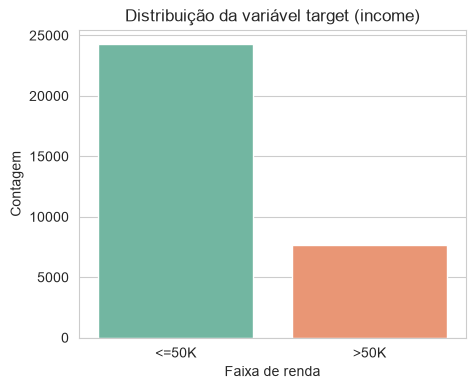

In [13]:
# 76% <=50K e 24% >50K
income_counts = df["income"].value_counts()
income_pct = df["income"].value_counts(normalize=True).round(3) * 100

print(income_counts)
print()
print(income_pct)

plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="income", hue="income", palette="Set2", legend=False)
plt.title("Distribuição da variável target (income)")
plt.xlabel("Faixa de renda")
plt.ylabel("Contagem")
plt.show()

### 1.5 Separação treino/teste

Fazemos o split antes de qualquer análise que possa vazar informação do conjunto de teste. Usamos `stratify` para preservar a proporção do target em ambos os conjuntos.

In [14]:
X = df.drop(columns=["income"])
y = df["income"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Treino:", X_train.shape, " Teste:", X_test.shape)
print()
print("Proporção no treino:\n", y_train.value_counts(normalize=True).round(3))
print("Proporção no teste:\n", y_test.value_counts(normalize=True).round(3))

df_train = X_train.copy()
df_train["income"] = y_train

Treino: (25557, 11)  Teste: (6390, 11)

Proporção no treino:
 income
<=50K    0.76
>50K     0.24
Name: proportion, dtype: float64
Proporção no teste:
 income
<=50K    0.759
>50K     0.241
Name: proportion, dtype: float64


## 2. Análise univariada

### 2.1 Variáveis numéricas: `age`, `education.num`, `fnlwgt`

In [15]:
num_vars = ["age", "education.num", "fnlwgt"]
df_train[num_vars].describe().T

,count,mean,std,min,25%,50%,75%,max
age,25557.0,38.456783,13.567446,17.0,28.0,37.0,47.0,90.0
education.num,25557.0,10.075361,2.551940,1.0,9.0,10.0,12.0,16.0
fnlwgt,25557.0,189813.951990,105876.236475,12285.0,117595.0,178319.0,237720.0,1484705.0


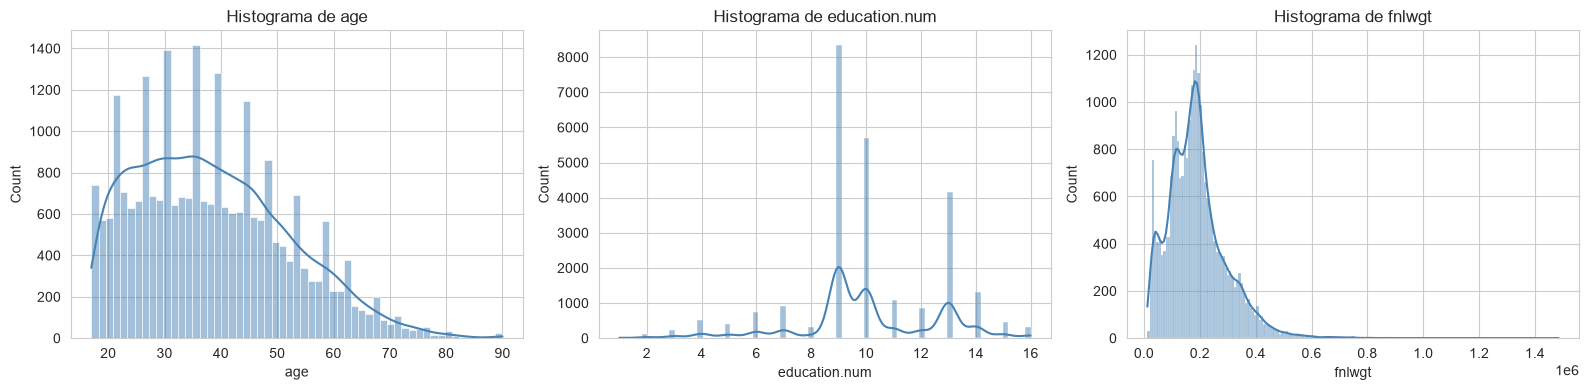

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, num_vars):
    sns.histplot(df_train[col], kde=True, ax=ax, color="steelblue")
    ax.set_title(f"Histograma de {col}")
plt.tight_layout()
plt.show()

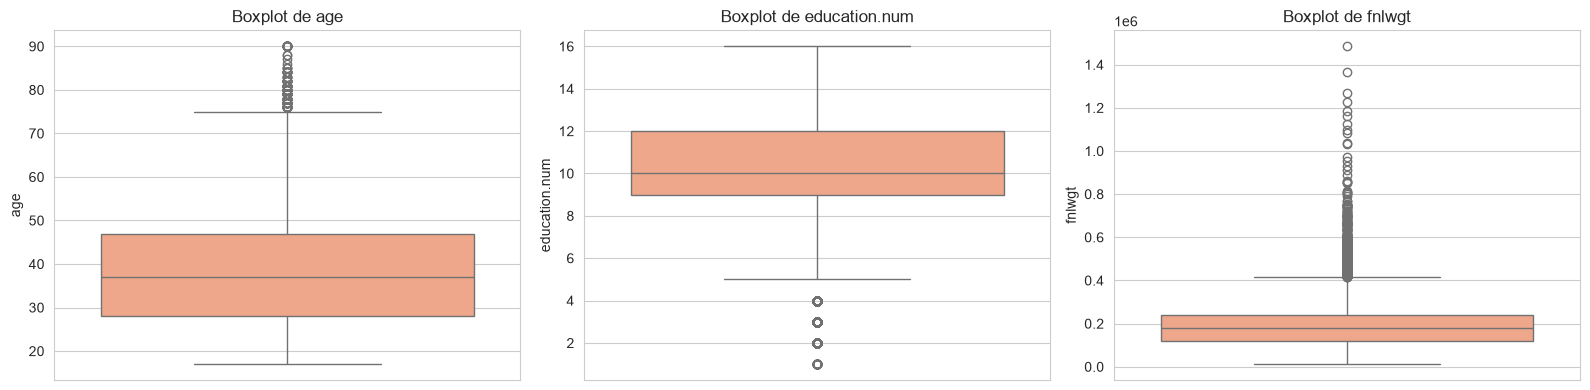

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, num_vars):
    sns.boxplot(y=df_train[col], ax=ax, color="lightsalmon")
    ax.set_title(f"Boxplot de {col}")
plt.tight_layout()
plt.show()

- Idade com distribuição concentrada entre 20 e 50 anos, leve assimetria direcionada à idades mais avançadas.
- Educação (numérica) concentrada em torno de 9 e 10 anos (anos finais da escola)
- fnlwgt com muitos outliers, coerente com peso amostral

### 2.2 Variáveis categóricas: workclass, marital.status, occupation


In [18]:
cat_vars = ["workclass", "marital.status", "occupation"]
for col in cat_vars:
    print(f"--- {col} ---")
    print(df_train[col].value_counts(dropna=False))
    print()

--- workclass ---
workclass
Private             17800
Self-emp-not-inc     2020
Local-gov            1658
NaN                  1425
State-gov            1018
Self-emp-inc          857
Federal-gov           762
Without-pay            10
Never-worked            7
Name: count, dtype: int64

--- marital.status ---
marital.status
Married-civ-spouse       11784
Never-married             8391
Divorced                  3501
Separated                  792
Widowed                    764
Married-spouse-absent      307
Married-AF-spouse           18
Name: count, dtype: int64

--- occupation ---
occupation
Craft-repair         3093
Exec-managerial      2987
Prof-specialty       2939
Adm-clerical         2849
Sales                2715
NaN                  2620
Other-service        2539
Machine-op-inspct    1522
Transport-moving     1184
Handlers-cleaners    1033
Farming-fishing       770
Tech-support          687
Protective-serv       503
Priv-house-serv       110
Armed-Forces            6
Name: cou

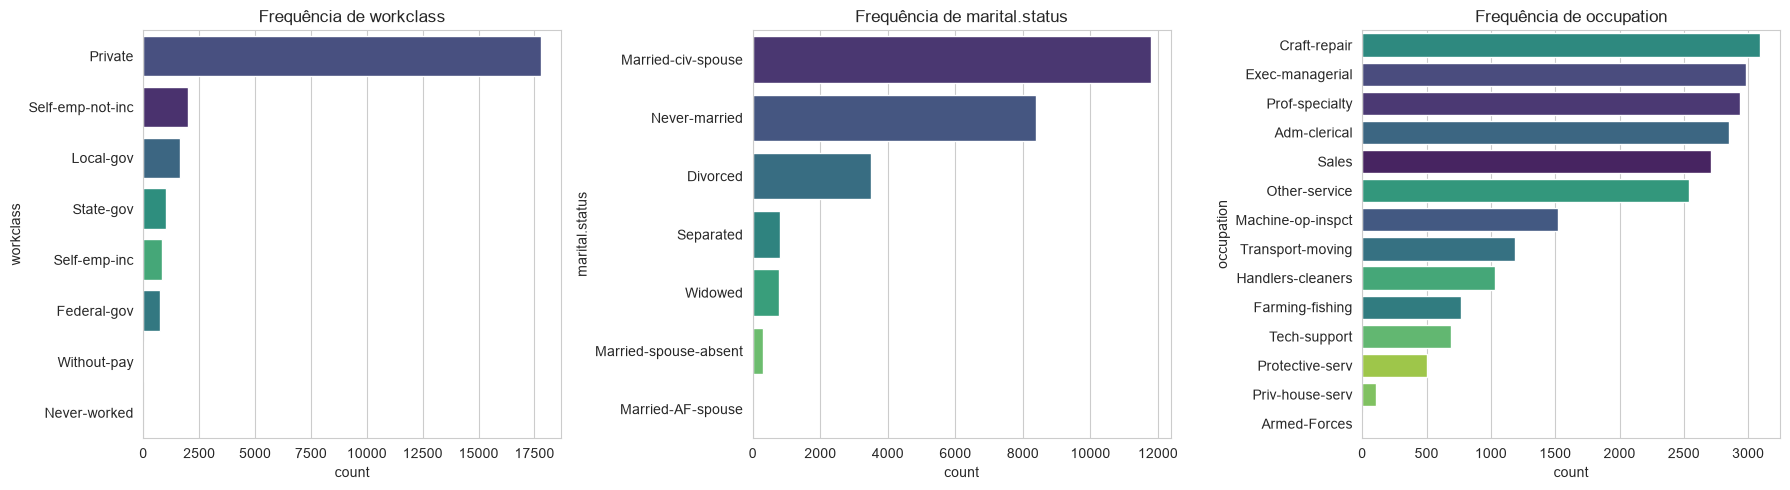

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, cat_vars):
    order = df_train[col].value_counts().index
    sns.countplot(data=df_train, y=col, order=order, hue=col, legend=False, palette="viridis", ax=ax)
    ax.set_title(f"Frequência de {col}")
plt.tight_layout()
plt.show()

- A maioria da categoria `workclass` é `Private`.
- `marital.status`: casados civilmente e nunca casados dominam
- `occupation` sem categoria dominante clara

## 3. Análise bivariada e multivariada

### 3.1 Correlação entre variáveis numéricas

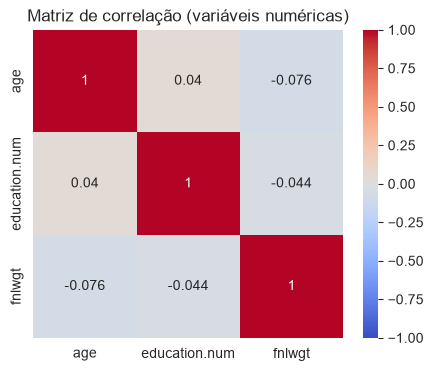

,age,education.num,fnlwgt
age,1.000000,0.039831,-0.076206
education.num,0.039831,1.000000,-0.044446
fnlwgt,-0.076206,-0.044446,1.000000


In [20]:
corr = df_train[num_vars].corr()
plt.figure(figsize=(5, 4))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de correlação (variáveis numéricas)")
plt.show()
corr

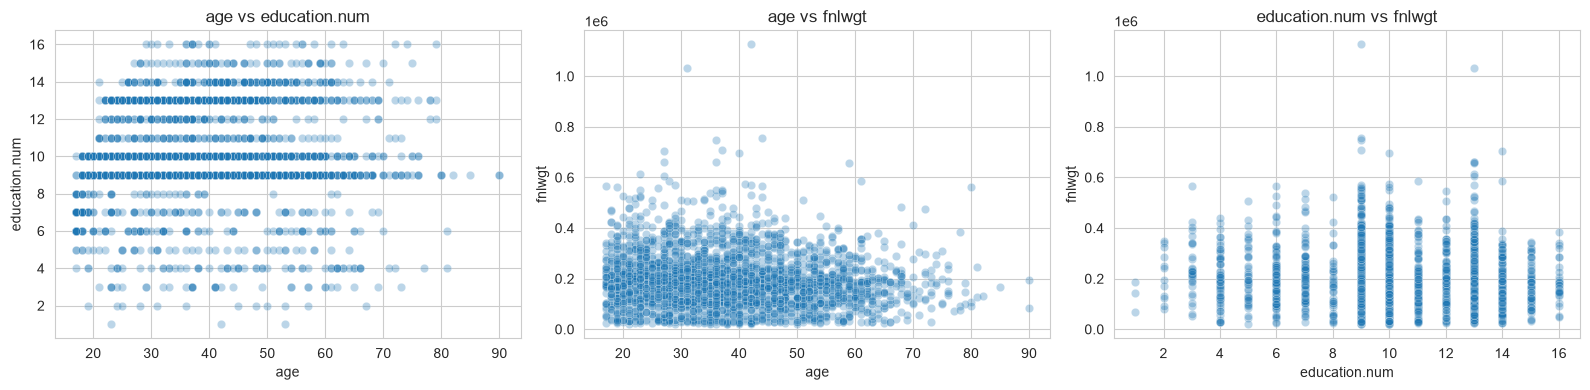

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
pairs = [("age", "education.num"), ("age", "fnlwgt"), ("education.num", "fnlwgt")]
for ax, (x, y_) in zip(axes, pairs):
    sns.scatterplot(data=df_train.sample(3000, random_state=RANDOM_STATE), x=x, y=y_, alpha=0.3, ax=ax)
    ax.set_title(f"{x} vs {y_}")
plt.tight_layout()
plt.show()

As correlações lineares entre as numéricas são fracas. `fnlwgt` praticamente não se relaciona com `age` nem `education.num`, reforçando que é uma variável de natureza distinta.

### 3.2 Variáveis categóricas vs. target `income`: `education`, `marital.status`, `workclass`

In [22]:
cat_vs_target = ["education", "marital.status", "workclass"]
for col in cat_vs_target:
    ct = pd.crosstab(df_train[col], df_train["income"], normalize="index").round(3) * 100
    print(f"--- % de >50K por categoria de {col} ---")
    print(ct.sort_values(">50K", ascending=False))
    print()

--- % de >50K por categoria de education ---
income        <=50K  >50K
education                
Doctorate      25.8  74.2
Prof-school    26.0  74.0
Masters        44.0  56.0
Bachelors      58.8  41.2
Assoc-voc      72.8  27.2
Assoc-acdm     74.6  25.4
Some-college   80.6  19.4
HS-grad        84.2  15.8
12th           92.6   7.4
10th           93.2   6.8
7th-8th        93.3   6.7
9th            94.8   5.2
11th           95.5   4.5
5th-6th        96.2   3.8
1st-4th        97.6   2.4
Preschool     100.0   0.0

--- % de >50K por categoria de marital.status ---
income                 <=50K  >50K
marital.status                    
Married-civ-spouse      55.2  44.8
Married-AF-spouse       61.1  38.9
Divorced                89.8  10.2
Married-spouse-absent   91.5   8.5
Widowed                 91.8   8.2
Separated               93.8   6.2
Never-married           95.6   4.4

--- % de >50K por categoria de workclass ---
income            <=50K  >50K
workclass                    
Self-emp-inc   

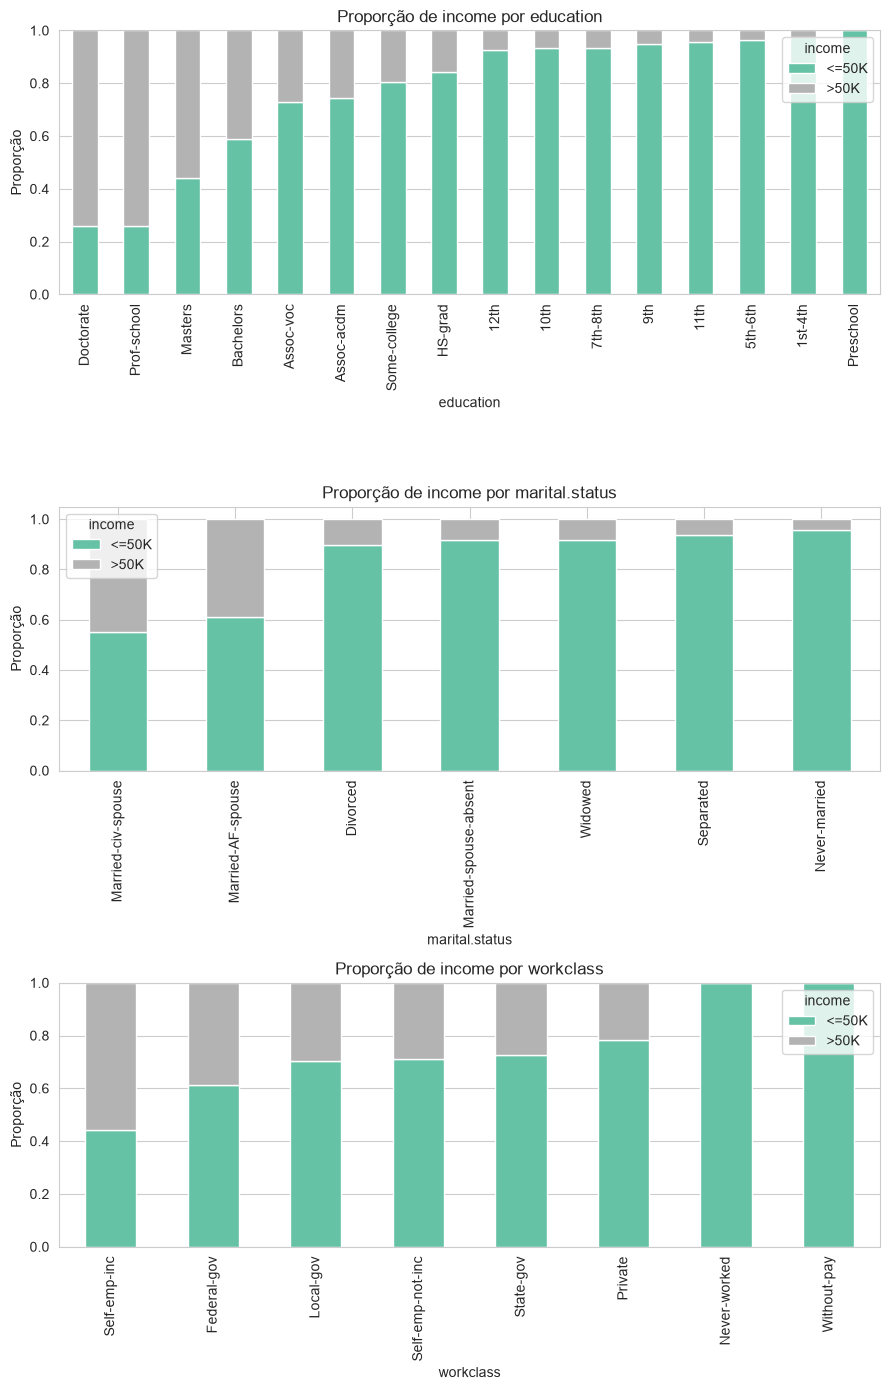

In [23]:
fig, axes = plt.subplots(3, 1, figsize=(9, 14))
for ax, col in zip(axes, cat_vs_target):
    ct = pd.crosstab(df_train[col], df_train["income"], normalize="index")
    ct = ct.sort_values(">50K", ascending=False)
    ct.plot(kind="bar", stacked=True, ax=ax, colormap="Set2")
    ax.set_title(f"Proporção de income por {col}")
    ax.set_ylabel("Proporção")
    ax.legend(title="income")
plt.tight_layout()
plt.show()

Há uma relação clara entre o ganho salarial, grau de escolaridade e estado civil. Geralmente pessoas casadas e com níveis mais altos de escolaridade apresentam uma proporção maior de income.

### 3.3 Numérica vs. categórica

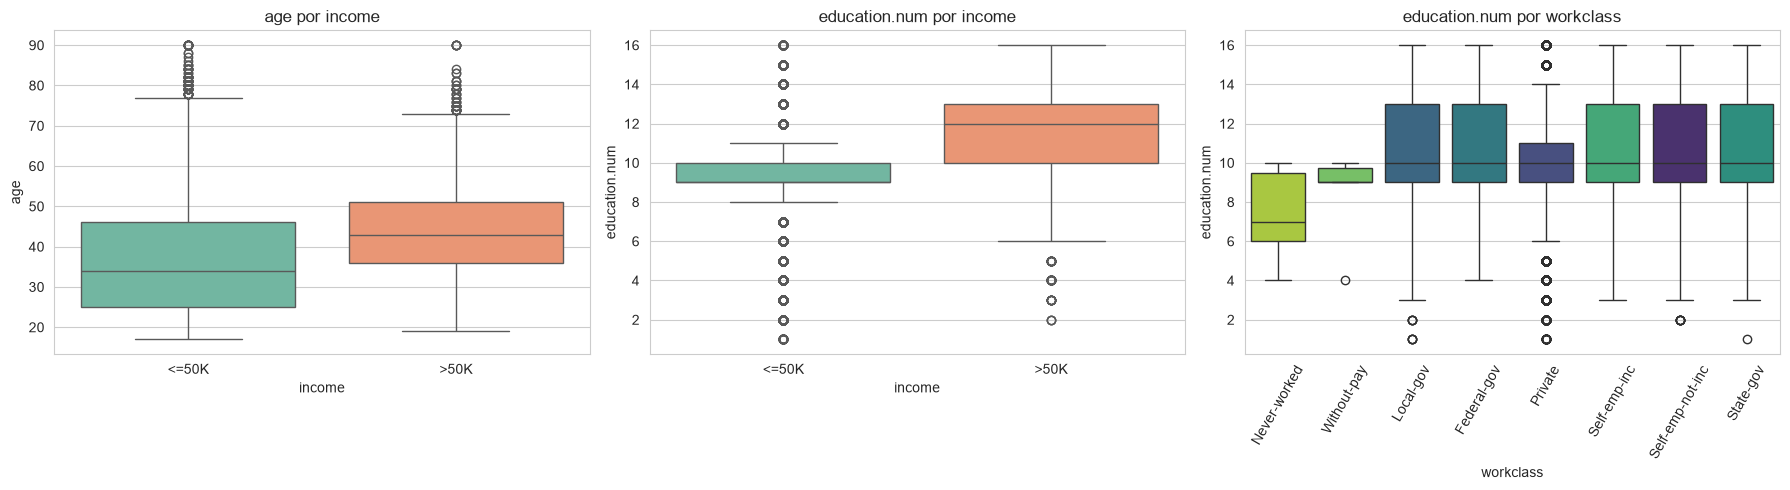

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df_train, x="income", y="age", hue="income", legend=False, ax=axes[0], palette="Set2")
axes[0].set_title("age por income")

sns.boxplot(data=df_train, x="income", y="education.num", hue="income", legend=False, ax=axes[1], palette="Set2")
axes[1].set_title("education.num por income")

order = df_train.groupby("workclass")["education.num"].median().sort_values().index
sns.boxplot(data=df_train, x="workclass", y="education.num", order=order, hue="workclass", legend=False, ax=axes[2], palette="viridis")
axes[2].set_title("education.num por workclass")
axes[2].tick_params(axis="x", rotation=60)

plt.tight_layout()
plt.show()

- Quem ganha >50K tende a ser mais velho e ter mais anos de educação.
- Os anos de ensino finalizados também variam conforme a classe social

## 4. Pré-processamento para modelagem

### 4.1 Estratégia para valores ausentes

Ausentes existem apenas em três colunas categóricas: `workclass`, `occupation`, `native.country` (poucas dezenas em `native.country`, ~5-6% nas outras duas). Ao invés de remover as linhas (perderíamos ~5.5% dos dados de forma não aleatória, `workclass` e `occupation` ausentes tendem a andar juntos), vamos imputar com uma categoria explícita `"Unknown"`. Isso preserva a informação de que o dado não foi informado, o que pode até ser preditivo (SimpleImputer com strategy="constant" faz isso).

### 4.2 Estratégia para outliers

`fnlwgt` tem outliers extremos, mas por ser um peso amostral (não uma medida pessoal), não faz sentido "corrigi-los" como erro. Aplicar transformação logarítmica (`log1p`) para reduzir a assimetria, mantendo todos os registros. Em `age`, os valores estão dentro de uma faixa plausível (não há outliers a tratar).

### 4.3 Estratégia de encoding

- Colunas nominais sem ordem (`workclass`, `marital.status`, `occupation`, `relationship`, `race`, `sex`, `native.country`): One-Hot Encoding, pois não há ordem natural entre categorias e o número de categorias é administrável (a maior é `native.country`, ~42 categorias).
- `education`: descartada da modelagem, pois `education.num` já carrega a mesma informação de forma numérica ordinal, evitando redundância/colinearidade perfeita.

### 4.4 Estratégia de normalização/padronização

StandardScaler (padronização, média 0 / desvio 1) para `age`, `education.num` e `log(fnlwgt)`, para que seja possível testar modelos sensíveis a escala. MinMax poderia ser utilizado no caso de redes neurais, mas o primeiro método mencionado apresenta critérios mais robustos.

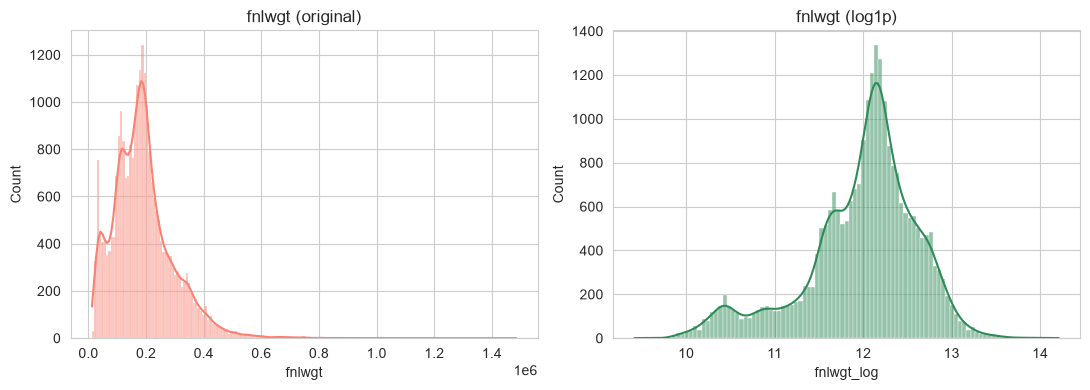

In [25]:
# Aplicando a transformação log em fnlwgt
df_train["fnlwgt_log"] = np.log1p(df_train["fnlwgt"])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df_train["fnlwgt"], kde=True, ax=axes[0], color="salmon")
axes[0].set_title("fnlwgt (original)")
sns.histplot(df_train["fnlwgt_log"], kde=True, ax=axes[1], color="seagreen")
axes[1].set_title("fnlwgt (log1p)")
plt.tight_layout()
plt.show()

### 4.5 Redução de dimensionalidade com PCA

Para visualizar a estrutura das variáveis numéricas, aplicamos **PCA (Principal Component Analysis)** em `age`, `education.num` e `fnlwgt`. Mantemos a decisão tomada anteriormente de aplicar `log1p` em `fnlwgt`, reduzindo sua assimetria antes da padronização.

O PCA é sensível à escala. Portanto, o ajuste segue esta ordem:

1. imputação pela mediana, caso apareça algum valor numérico ausente;
2. transformação `log1p` somente em `fnlwgt`;
3. padronização com `StandardScaler`;
4. projeção nas componentes principais.

Todas as transformações são ajustadas **somente no conjunto de treino**, evitando vazamento de informações do conjunto de teste.


In [26]:
from sklearn.preprocessing import FunctionTransformer
from sklearn.metrics import silhouette_score

pca_numeric_cols = ["age", "education.num", "fnlwgt"]

def aplicar_log_fnlwgt(dados):
    # Aplica log1p apenas à terceira coluna, que corresponde a fnlwgt.
    dados_transformados = np.asarray(dados, dtype=float).copy()
    dados_transformados[:, 2] = np.log1p(dados_transformados[:, 2])
    return dados_transformados

pca_visual_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("log_fnlwgt", FunctionTransformer(aplicar_log_fnlwgt, validate=False)),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=2)),
])

X_train_pca = pca_visual_pipeline.fit_transform(X_train[pca_numeric_cols])
X_test_pca = pca_visual_pipeline.transform(X_test[pca_numeric_cols])

pca_resultado = pd.DataFrame(
    X_train_pca,
    columns=["PC1", "PC2"],
    index=X_train.index,
)
pca_resultado["income"] = y_train

pca_ajustado = pca_visual_pipeline.named_steps["pca"]
variancia_explicada = pca_ajustado.explained_variance_ratio_

print(f"Variância explicada pela PC1: {variancia_explicada[0]:.2%}")
print(f"Variância explicada pela PC2: {variancia_explicada[1]:.2%}")
print(f"Variância explicada acumulada: {variancia_explicada.sum():.2%}")

Variância explicada pela PC1: 36.45%
Variância explicada pela PC2: 32.23%
Variância explicada acumulada: 68.68%


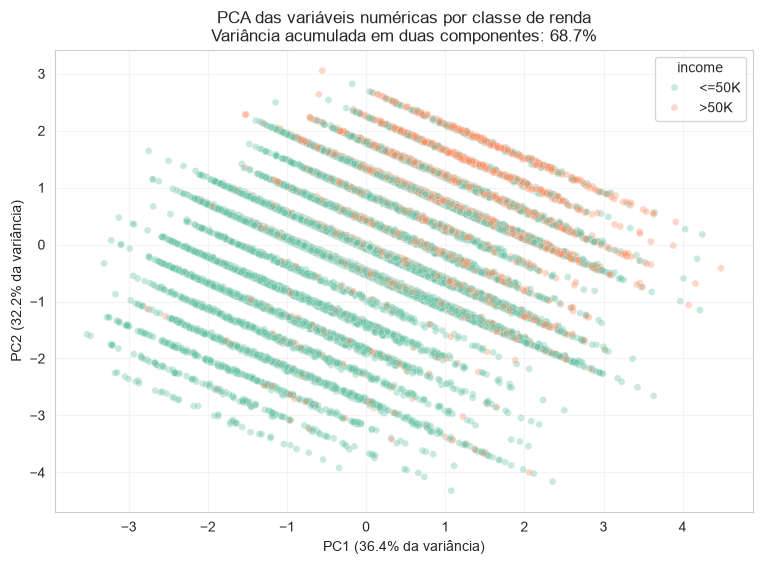

In [27]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=pca_resultado,
    x="PC1",
    y="PC2",
    hue="income",
    palette="Set2",
    alpha=0.35,
    s=25,
)
plt.title(
    "PCA das variáveis numéricas por classe de renda\n"
    f"Variância acumulada em duas componentes: {variancia_explicada.sum():.1%}"
)
plt.xlabel(f"PC1 ({variancia_explicada[0]:.1%} da variância)")
plt.ylabel(f"PC2 ({variancia_explicada[1]:.1%} da variância)")
plt.legend(title="income")
plt.grid(alpha=0.2)
plt.show()

### 4.6 Separabilidade das classes e importância das features

O gráfico permite observar se os registros de `<=50K` e `>50K` ocupam regiões distintas. Para complementar a inspeção visual, calculamos:

- a distância entre os centroides das duas classes;
- a dispersão média dos pontos dentro de cada classe;
- a razão entre distância e dispersão;
- o coeficiente de silhueta usando `income` como rótulo.

Quanto maior a razão entre distância e dispersão, mais afastados estão os centros das classes em relação à variação interna. A silhueta varia de $-1$ a $1$: valores próximos de $1$ indicam grupos bem separados, próximos de $0$ indicam sobreposição e valores negativos sugerem que muitos pontos estão mais próximos da outra classe.


In [28]:
centroides = pca_resultado.groupby("income")[["PC1", "PC2"]].mean()
display(centroides.round(3))

distancia_centroides = np.linalg.norm(centroides.iloc[0] - centroides.iloc[1])

dispersoes = []
for classe, grupo in pca_resultado.groupby("income"):
    pontos = grupo[["PC1", "PC2"]].to_numpy()
    centro = centroides.loc[classe].to_numpy()
    dispersoes.append(np.linalg.norm(pontos - centro, axis=1).mean())

dispersao_media = np.mean(dispersoes)
razao_separacao = distancia_centroides / dispersao_media

# O silhouette_score tem custo alto para todos os registros. Uma amostra
# estratificada de até 5.000 pontos é suficiente para esta análise exploratória.
if len(pca_resultado) <= 5000:
    amostra_silhueta = pca_resultado
else:
    _, amostra_silhueta = train_test_split(
        pca_resultado,
        test_size=5000,
        random_state=RANDOM_STATE,
        stratify=pca_resultado["income"],
    )
pontos_amostra = amostra_silhueta[["PC1", "PC2"]]
classes_amostra = amostra_silhueta["income"]
silhueta = silhouette_score(pontos_amostra, classes_amostra)

print(f"Distância entre os centroides: {distancia_centroides:.3f}")
print(f"Dispersão média dentro das classes: {dispersao_media:.3f}")
print(f"Razão separação/dispersão: {razao_separacao:.3f}")
print(f"Coeficiente de silhueta: {silhueta:.3f}")

if silhueta < 0.10:
    print(
        "Interpretação: as classes apresentam forte sobreposição no espaço formado "
        "pelas duas componentes. As variáveis numéricas, sozinhas, não produzem "
        "uma separação clara entre as faixas de renda."
    )
elif silhueta < 0.30:
    print(
        "Interpretação: existe alguma estrutura de separação, mas ainda há "
        "sobreposição considerável entre as classes."
    )
else:
    print(
        "Interpretação: as classes apresentam separação relevante no espaço "
        "das duas componentes principais."
    )


,PC1,PC2
income,,
<=50K,-0.178,-0.116
>50K,0.562,0.367


Distância entre os centroides: 0.884
Dispersão média dentro das classes: 1.197
Razão separação/dispersão: 0.738
Coeficiente de silhueta: 0.068
Interpretação: as classes apresentam forte sobreposição no espaço formado pelas duas componentes. As variáveis numéricas, sozinhas, não produzem uma separação clara entre as faixas de renda.


Os pesos, ou *loadings*, mostram quanto cada variável contribui para a formação de cada componente. Um valor absoluto maior representa maior contribuição; o sinal positivo ou negativo informa a direção da relação dentro do componente.

É importante não confundir contribuição para o PCA com importância preditiva para `income`: o PCA é não supervisionado e não utiliza o target ao criar as componentes. A importância para a classificação deverá ser confirmada na APS 2 com técnicas como importância por permutação ou SHAP.


,PC1,PC2,importancia_nas_duas_PCs
education.num,0.511,0.859,1.000
fnlwgt,-0.606,0.377,0.714
age,0.609,-0.346,0.701


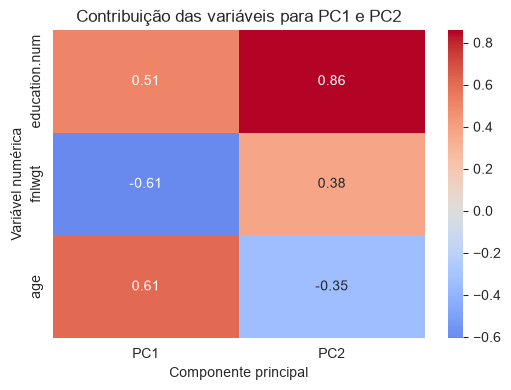

Maior contribuição absoluta em PC1: age (loading = 0.609)
Maior contribuição absoluta em PC2: education.num (loading = 0.859)


In [29]:
loadings = pd.DataFrame(
    pca_ajustado.components_.T,
    index=pca_numeric_cols,
    columns=["PC1", "PC2"],
)
loadings["importancia_nas_duas_PCs"] = np.sqrt(
    loadings["PC1"] ** 2 + loadings["PC2"] ** 2
)
loadings = loadings.sort_values("importancia_nas_duas_PCs", ascending=False)

display(loadings.round(3))

plt.figure(figsize=(6, 4))
sns.heatmap(
    loadings[["PC1", "PC2"]],
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
)
plt.title("Contribuição das variáveis para PC1 e PC2")
plt.xlabel("Componente principal")
plt.ylabel("Variável numérica")
plt.show()

for componente in ["PC1", "PC2"]:
    mais_importante = loadings[componente].abs().idxmax()
    peso = loadings.loc[mais_importante, componente]
    print(
        f"Maior contribuição absoluta em {componente}: "
        f"{mais_importante} (loading = {peso:.3f})"
    )


### 4.7 Pipeline completo de pré-processamento

O pipeline abaixo incorpora as decisões justificadas nas seções anteriores:

- `education` é removida da modelagem por duplicar a informação de `education.num`;
- valores numéricos ausentes são imputados pela mediana;
- `log1p` é aplicado somente a `fnlwgt`;
- as três variáveis numéricas são padronizadas;
- o PCA reduz as três variáveis numéricas para **duas componentes principais**, mantendo a mesma representação usada na análise exploratória;
- valores categóricos ausentes recebem a categoria explícita `Unknown`;
- variáveis categóricas recebem One-Hot Encoding;
- categorias novas encontradas no teste são ignoradas, evitando erros na transformação.

O ajuste do pré-processamento ocorre apenas no treino. Na APS 2, `preprocessor` poderá ser colocado diretamente antes de um classificador em outro `Pipeline`.


In [30]:
# education é excluída porque education.num representa a mesma informação.
model_numeric_cols = ["age", "education.num", "fnlwgt"]
model_categorical_cols = [
    "workclass",
    "marital.status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native.country",
]

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("log_fnlwgt", FunctionTransformer(aplicar_log_fnlwgt, validate=False)),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=2)),
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, model_numeric_cols),
        ("categorical", categorical_pipeline, model_categorical_cols),
    ],
    remainder="drop",
)

# fit_transform somente no treino; no teste usamos apenas transform.
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

pca_pipeline_modelagem = preprocessor.named_transformers_["numeric"].named_steps["pca"]

print("Formato original do treino:", X_train.shape)
print("Formato após pré-processamento:", X_train_processed.shape)
print("Formato original do teste:", X_test.shape)
print("Formato após pré-processamento:", X_test_processed.shape)
print(
    "Componentes numéricas mantidas pelo PCA:",
    pca_pipeline_modelagem.n_components_,
)
print(
    "Variância numérica preservada:",
    f"{pca_pipeline_modelagem.explained_variance_ratio_.sum():.2%}",
)

assert X_train_processed.shape[0] == X_train.shape[0]
assert X_test_processed.shape[0] == X_test.shape[0]
assert not np.isnan(X_train_processed.data).any() if hasattr(X_train_processed, "data") else not np.isnan(X_train_processed).any()

print("Pipeline validado e pronto para receber um classificador na APS 2.")


Formato original do treino: (25557, 11)
Formato após pré-processamento: (25557, 88)
Formato original do teste: (6390, 11)
Formato após pré-processamento: (6390, 88)
Componentes numéricas mantidas pelo PCA: 2
Variância numérica preservada: 68.68%
Pipeline validado e pronto para receber um classificador na APS 2.


### 4.8 Síntese dos resultados do PCA

A análise deve considerar conjuntamente a porcentagem de variância preservada, o gráfico, a métrica de silhueta e os *loadings*. Se as cores estiverem muito misturadas e a silhueta estiver próxima de zero, conclui-se que `age`, `education.num` e `fnlwgt`, projetadas em duas dimensões, não separam completamente as classes de renda. Isso não torna as variáveis inúteis: `age` e `education.num` já apresentaram diferenças entre as classes na análise bivariada, mas a fronteira provavelmente depende também das variáveis categóricas e de relações não lineares.

Os *loadings* identificam quais variáveis mais determinam cada eixo do gráfico. Já a importância **preditiva** será avaliada na etapa de classificação. O pipeline final garante que imputação, transformação, padronização, PCA e encoding sejam aprendidos somente a partir do treino e aplicados da mesma maneira a novos dados.
